In [1]:
import sys
import math
import os
import torch
sys.path.append(os.path.abspath('../'))

from natsort import natsorted
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
from tqdm import tqdm

# Add both project root and src/ to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))  # <-- add this

from src.dataset import deterministic_sample
from src.egnn import EGNN
from src.fm import FlowMatching
from src.pbc_config import wrap, min_image, BOX
from src.utils import load_config, gpu_knn_graph_pbc_batch, scale_thetas, SinusoidalThetaEmbedding

from src.validation import get_tpcf

import numpy as np
import pandas as pd 
import torch.nn as nn
import matplotlib.pyplot as plt

/home/bartb/venvs/boids/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def det_prior(x1):
    g = torch.Generator(device=x1.device)
    g.manual_seed(42)

    x0 = torch.rand(x1.shape, device=x1.device, generator=g)
    return x0

def sample_xt(x0, x1, t, batch):
    t = t[batch]

    delta = min_image(x1 - x0, **BOX)
    mu_t = x0+t*delta
    sigma_t = 0
    
    x = mu_t + sigma_t * torch.randn_like(x1)

    return wrap(x, **BOX)
    

In [3]:
run = "20260316_010618"
model_folder = f"/gpfs/home4/bartb/T5000/results/run_{run}/"
config_dir = f"/gpfs/home4/bartb/T5000/results/run_{run}/train_configs.yaml"
config = load_config(config_dir)

In [4]:
egnn = EGNN(t_embed_dim=config["model"]["fm"]["t_embed_dim"],
                input_node_d=config["model"]["egnn"]["input_node_d"],
                input_theta_d=5,
                theta_param_embd_dim=config["model"]["egnn"]["theta_param_embd_dim"],
                hidden_nf=config["model"]["egnn"]["hidden_nf"],
                latent_nf=config["model"]["egnn"]["latent_nf"],
                theta_nf=config["model"]["egnn"]["theta_nf"],
                n_layers=config["model"]["egnn"]["n_layers"],
                mlp_layers=config["model"]["egnn"]["mlp_layers"],
                single_layer=config["model"]["egnn"]["single_layer"],
                recurrent=config["model"]["egnn"]["recurrent"],
                activation=nn.SiLU(),
                norm=config["model"]["egnn"]["norm"],
                attention=config["model"]["egnn"]["attention"],
                scale_pred=config["model"]["egnn"]["scale_pred"],
                coords_weight=config["model"]["egnn"]["coords_weight"],
                norm_diff=config["model"]["egnn"]["norm_diff"])
    
model = FlowMatching(sigma_0=config["model"]["fm"]["sigma_0"],
                     sigma_sched=config["model"]["fm"]["sigma_sched"],
                     t_embed_dim=config["model"]["fm"]["t_embed_dim"],
                     version=config["model"]["fm"]["version"],
                     vnet=egnn,
                     batch_size=config["training"]["batch_size"],
                     prior=config["model"]["fm"]["prior"],
                     k=config["model"]["fm"]["k"],
                     t_embed=config["model"]["fm"]["t_embed"],
                     n_halos=config["model"]["fm"]["n_halos"],
                     dim=3
                     )


        Initializing Flow Matching model with:
        - sigma_0: 0.2
        - sigma_sched: False
        - t_embed_dim: 64
        - version: icfm
        - batch_size: 16
        - prior: uniform
        - k: 32
        - t_embed: sinusoidal
        - n_halos: 5000
        - dim: 3
              


In [5]:
### Create artificial Data object
sample = deterministic_sample(
    "../Data",
    "../Data")

device = torch.device("cpu")
batch_size = 1
theta_embedding = SinusoidalThetaEmbedding(32)

checkpoints = [f for f in os.listdir(model_folder) if (f.endswith('.pt') or f.endswith('.pth')) and 'final' not in f]
checkpoints = natsorted(checkpoints)

final_ckpt = [f for f in os.listdir(model_folder) if 'final' in f]
if final_ckpt:
    checkpoints.append(final_ckpt[0])

epochs = []
t_norms = []
theta_norms = []

for ckpt_file in tqdm(checkpoints):
    if 'final' in ckpt_file:
        epoch = epochs[-1] + 100 if epochs else 0  # place it after the last checkpoint
    else:
        epoch = int(ckpt_file.replace('model_epoch_', '').replace('.pth', ''))    
    ckpt_path = os.path.join(model_folder, ckpt_file)
    checkpoint = torch.load(ckpt_path, map_location=torch.device('cpu'))
    new_state_dict = {k.replace("module.", ""): v for k, v in checkpoint["model_state"].items()}  
    model.load_state_dict(new_state_dict)
    model.eval()

    # Sample time and embed
    torch.manual_seed(42)
    t = torch.rand(size=(batch_size, 1), device=device).requires_grad_(True)
    t_embedded = model.time_embedding(t)
    
    # Unpack training data samples and construct graph:
    x1 = sample.x
    x0 = det_prior(x1)
    mass = sample.mass.view(-1, 1)
    vel = sample.vel
    batch = torch.zeros(5000, dtype=int)
    theta = scale_thetas(sample.theta)
    node_counts_per_graph = torch.bincount(batch)
    edge_index = gpu_knn_graph_pbc_batch(x1, 32, batch, device)
    assert x1.shape[0] == torch.sum(node_counts_per_graph), "Number of nodes in x is different than number of halos per graph."
    
    # Construct features
    h_in = torch.ones_like(x1[:, :1])
    
    # Sample x_t from probability path p_t
    x_t = sample_xt(x0=x0, x1=x1, t=t, batch=batch) 
    theta = theta.view(-1, 5).clone().detach().requires_grad_(True)
    target_vel = min_image(x1 - x0, **BOX) 
    pred_vel = egnn(h_in, x_t, t_embedded, batch, edge_index, theta=theta)
    loss = ((pred_vel - target_vel) ** 2).mean()
    
    # Backprop
    loss.backward()

    epochs.append(epoch)
    t_norms.append(t.grad.norm().item())
    theta_norms.append(theta.grad.norm().item())
    
    # # Check gradients
    # print("theta grad:", theta.grad)
    # print("t grad:", t.grad)
    # print("theta grad norm:", theta.grad.norm().item())
    # print("t grad norm:", t.grad.norm().item())
    
    # For comparison, also check time gradient:
    # (you'd need to do the same .requires_grad_(True) trick for t_embedded)
print(f'''
Done!
Length of t_norms = {len(t_norms)}
Length of theta_norms = {len(theta_norms)}''')

  0%|          | 0/31 [00:00<?, ?it/s]/scratch-local/bartb.20799000/ipykernel_677942/1477285461.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Done!
Length of t_norms = 31
Length of theta_norms = 31


In [6]:
def plot_gradient_norms(epochs, t_norms, theta_norms):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(epochs, t_norms, label='t grad norm', marker='o')
    ax1.plot(epochs, theta_norms, label='θ grad norm', marker='o')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Gradient Norm')
    ax1.set_title('Raw Gradient Norms')
    ax1.set_yscale('log')
    ax1.set_xticks(torch.arange(100, epochs[-1]+100, 100))
    ax1.legend()
    ax1.grid(True)
    
    ratios = [t / th for t, th in zip(t_norms, theta_norms)]
    ax2.plot(epochs, ratios, marker='o', color='red')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('t_norm / θ_norm')
    ax2.set_title('Gradient Norm Ratio (t / θ)')
    ax2.set_xticks(torch.arange(100, epochs[-1]+100, 100))
    ax2.grid(True)
    
    plt.tight_layout()
    # plt.savefig('gradient_norms.png', dpi=150)
    plt.show()

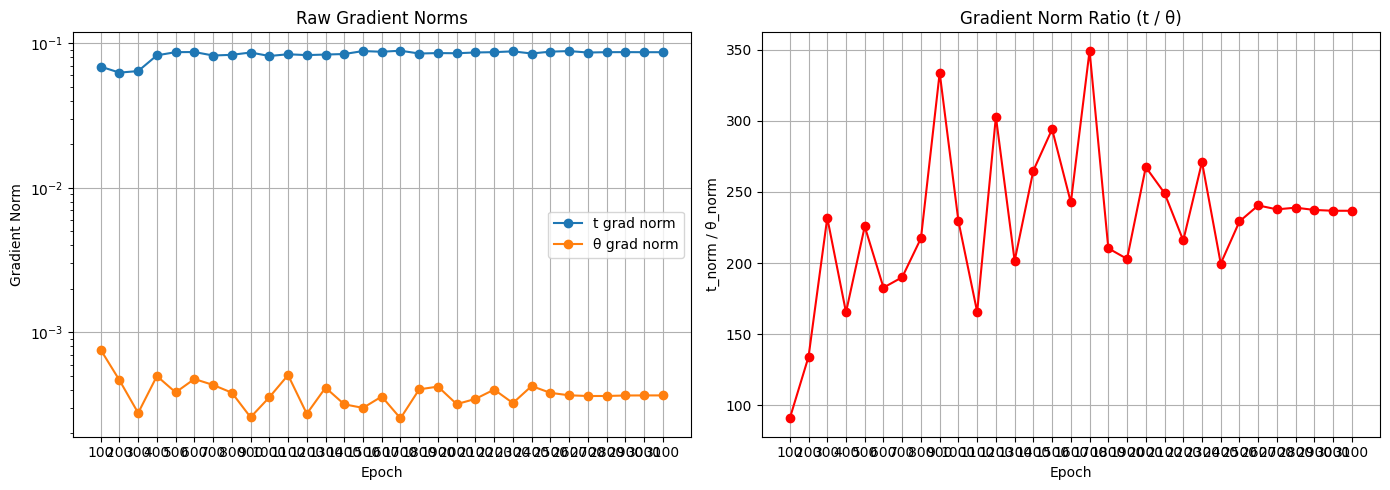

In [7]:
plot_gradient_norms(epochs, t_norms, theta_norms)